# Stage 8 — Causal fairness intervention via concept erasure

Stage 7 showed the fine-tuned classifier's decisions are gender-disparate (EO ≈ 0.52). **Is that disparity *carried by* the shortcut subspace of the representation?** We erase that subspace from the fine-tuned `[CLS]` vector, run the **real, unchanged classifier head**, and re-measure the gap. The intervention is exact: `head(cls)` reproduces the model's logits to 0.0.

Conditions (projection fit on **train** only, gap measured on the held-out **val** split):

| condition | erases | role |
|---|---|---|
| `baseline` | nothing | reference gap |
| `shortcut-erase` | the 8 shortcut features | **the causal test** |
| `gender-erase` | binary gender (rank 1) | ceiling — total gender-attributable harm |
| `random-erase` | N(0,1) targets, rank-matched, 10 seeds | **indispensable control** |

We track overall label AUC (collateral damage) and post-erasure gender decodability (sanity). **Erasure method: LEACE** (Belrose et al. 2023), closed form: `r(x) = μ + Σ^½ (I − QQᵀ) Σ^{−½}(x − μ)`, `Q` = orthonormal basis of `colspace(Σ^{−½} Cov(X,Z))` — guarantees `Cov(r(X),Z)=0` with the minimal-norm linear edit.

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore'); os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
from transformers import AutoModelForSequenceClassification

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = 'data/fairness'; os.makedirs(OUT, exist_ok=True); N_SEEDS = 10
MODELS = {'distilroberta-ft': ('data/stage2_finetuned/ft_model', 'data/stage2_finetuned/cls_embeddings_finetuned.npy'),
          'mentalroberta-ft': ('data/stage2_mentalroberta/ft_model', 'data/stage2_mentalroberta/finetuned/cls_embeddings.npy')}
SHORTCUTS = json.load(open('data/stage1/stage1_results.json'))['shortcut_features']

df = pd.read_pickle('data/stage1/features_18_extracted.pkl'); df['text'] = df['text'].fillna('')
GCOL = 'gender_label' if 'gender_label' in df.columns else 'gender'
if 'binary_label' not in df.columns: df['binary_label'] = (~df['TID'].str.contains('control')).astype(int)
tr_idx, va_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42, stratify=df['binary_label'].values)
y_all = df['binary_label'].values.astype(int)
g_all = (df[GCOL].values == 'female').astype(int)
Zs_all = StandardScaler().fit_transform(df[SHORTCUTS].fillna(0).values.astype(float))
print('shortcuts:', SHORTCUTS)

shortcuts: ['fp_singular', 'analytic', 'body_health', 'post_length', 'self_ref_rumination', 'hedge_density', 'negative_emotion', 'emotional_feeling']


In [2]:
# ── LEACE closed form (float64) ──────────────────────────────────────────────
def leace_fit(X, Z, eps=1e-3):
    X = torch.as_tensor(X, dtype=torch.float64); Z = torch.as_tensor(Z, dtype=torch.float64)
    if Z.ndim == 1: Z = Z[:, None]
    mu = X.mean(0); Xc = X - mu; Zc = Z - Z.mean(0); n = X.shape[0]
    Sig = (Xc.T @ Xc) / n
    Sig = Sig + eps * torch.trace(Sig) / Sig.shape[0] * torch.eye(Sig.shape[0], dtype=torch.float64)
    lam, V = torch.linalg.eigh(Sig); lam = torch.clamp(lam, min=1e-12)
    half = V @ torch.diag(lam.sqrt()) @ V.T; ihalf = V @ torch.diag(lam.rsqrt()) @ V.T
    M = ihalf @ ((Xc.T @ Zc) / n)
    U, S, _ = torch.linalg.svd(M, full_matrices=False)
    r = int((S > 1e-6 * S.max()).sum()) if S.numel() else 0
    Q = U[:, :r]; P = torch.eye(Sig.shape[0], dtype=torch.float64) - Q @ Q.T
    return mu, half @ P @ ihalf, r

def leace_apply(X, fit):
    mu, A, _ = fit; X = torch.as_tensor(X, dtype=torch.float64)
    return ((X - mu) @ A.T + mu).numpy()

def rates(yt, yp, m):
    tn, fp, fn, tp = confusion_matrix(yt[m], yp[m], labels=[0, 1]).ravel()
    return (fp/(fp+tn) if fp+tn else np.nan, tp/(tp+fn) if tp+fn else np.nan)

def fairness(prob, yt, g, thr=0.5):
    yp = (prob >= thr).astype(int)
    ff, tf = rates(yt, yp, g == 1); fm, tm = rates(yt, yp, g == 0)
    return dict(auc=roc_auc_score(yt, prob), fpr_gap=ff-fm, tpr_gap=tf-tm,
                eo=max(abs(ff-fm), abs(tf-tm)), sel_gap=yp[g==1].mean()-yp[g==0].mean())

In [3]:
rows = []
for name, (mdir, cls_path) in MODELS.items():
    print(f'\n========== {name} ==========')
    model = AutoModelForSequenceClassification.from_pretrained(mdir, dtype=torch.float32).to(DEVICE).eval()
    head = model.classifier
    @torch.no_grad()
    def head_prob(cls_np):
        o = []
        for i in range(0, len(cls_np), 4096):
            x = torch.as_tensor(cls_np[i:i+4096], dtype=torch.float32, device=DEVICE)
            x = torch.tanh(head.dense(head.dropout(x)))
            o.append(torch.softmax(head.out_proj(head.dropout(x)), -1)[:, 1].cpu().numpy())
        return np.concatenate(o)
    cls_all = np.load(cls_path).astype(np.float32); assert cls_all.shape[0] == len(df)
    cls_tr, cls_va = cls_all[tr_idx], cls_all[va_idx]; y_va, g_va = y_all[va_idx], g_all[va_idx]
    def gdec(tr_e, va_e):
        sc = StandardScaler().fit(tr_e)
        clf = LogisticRegression(max_iter=2000).fit(sc.transform(tr_e), g_all[tr_idx])
        return roc_auc_score(g_va, clf.predict_proba(sc.transform(va_e))[:, 1])
    def rec(cond, prob, gauc, rank):
        f = fairness(prob, y_va, g_va); rows.append({'model': name, 'condition': cond, 'rank': rank, 'gender_auc': gauc, **f})
        print(f"  {cond:16s} rank={rank:>3} | AUC={f['auc']:.3f} FPRgap={f['fpr_gap']:+.3f} "
              f"TPRgap={f['tpr_gap']:+.3f} EO={f['eo']:.3f} | genderAUC={gauc:.3f}")
    rec('baseline', head_prob(cls_va), gdec(cls_tr, cls_va), 0)
    fs = leace_fit(cls_tr, Zs_all[tr_idx]); cs_v, cs_t = leace_apply(cls_va, fs), leace_apply(cls_tr, fs)
    rec('shortcut-erase', head_prob(cs_v), gdec(cs_t, cs_v), fs[2])
    fg = leace_fit(cls_tr, g_all[tr_idx].astype(float)); cg_v, cg_t = leace_apply(cls_va, fg), leace_apply(cls_tr, fg)
    rec('gender-erase', head_prob(cg_v), gdec(cg_t, cg_v), fg[2])
    k = Zs_all.shape[1]; rnd = []
    for seed in range(N_SEEDS):
        Zr = np.random.default_rng(seed).standard_normal((len(df), k))
        f = fairness(head_prob(leace_apply(cls_va, leace_fit(cls_tr, Zr[tr_idx]))), y_va, g_va)
        rnd.append((f['auc'], f['fpr_gap'], f['tpr_gap'], f['eo']))
    rnd = np.array(rnd)
    print(f"  random-erase(k={k},{N_SEEDS} seeds): AUC={rnd[:,0].mean():.3f} EO={rnd[:,3].mean():.3f}±{rnd[:,3].std():.3f}")
    rows.append({'model': name, 'condition': 'random-erase', 'rank': k, 'gender_auc': np.nan,
                 'auc': rnd[:,0].mean(), 'fpr_gap': rnd[:,1].mean(), 'tpr_gap': rnd[:,2].mean(), 'eo': rnd[:,3].mean(),
                 'sel_gap': np.nan, 'auc_sd': rnd[:,0].std(), 'fpr_gap_sd': rnd[:,1].std(),
                 'tpr_gap_sd': rnd[:,2].std(), 'eo_sd': rnd[:,3].std()})
    del model; torch.cuda.empty_cache()
res = pd.DataFrame(rows); res.to_csv(f'{OUT}/causal_intervention.csv', index=False)
print('\n', res.to_string(index=False))


========== distilroberta-ft ==========


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

  baseline         rank=  0 | AUC=0.805 FPRgap=+0.254 TPRgap=+0.519 EO=0.519 | genderAUC=0.984


  shortcut-erase   rank=  8 | AUC=0.699 FPRgap=+0.177 TPRgap=+0.272 EO=0.272 | genderAUC=0.973


  gender-erase     rank=  1 | AUC=0.750 FPRgap=-0.039 TPRgap=-0.027 EO=0.039 | genderAUC=0.498


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  baseline         rank=  0 | AUC=0.816 FPRgap=+0.253 TPRgap=+0.519 EO=0.519 | genderAUC=0.981


  shortcut-erase   rank=  8 | AUC=0.716 FPRgap=+0.164 TPRgap=+0.284 EO=0.284 | genderAUC=0.970


  gender-erase     rank=  1 | AUC=0.762 FPRgap=-0.035 TPRgap=-0.017 EO=0.035 | genderAUC=0.504


  random-erase(k=8,10 seeds): AUC=0.814 EO=0.514±0.003

            model      condition  rank  gender_auc      auc   fpr_gap   tpr_gap       eo  sel_gap   auc_sd  fpr_gap_sd  tpr_gap_sd    eo_sd
distilroberta-ft       baseline     0    0.984400 0.805473  0.254476  0.518882 0.518882 0.409691      NaN         NaN         NaN      NaN
distilroberta-ft shortcut-erase     8    0.972739 0.698534  0.177452  0.272010 0.272010 0.240945      NaN         NaN         NaN      NaN
distilroberta-ft   gender-erase     1    0.498191 0.750088 -0.038686 -0.027194 0.038686 0.039613      NaN         NaN         NaN      NaN
distilroberta-ft   random-erase     8         NaN 0.803806  0.251937  0.507286 0.507286      NaN 0.001052    0.003425    0.008123 0.008123
mentalroberta-ft       baseline     0    0.980867 0.815543  0.252938  0.518856 0.518856 0.409706      NaN         NaN         NaN      NaN
mentalroberta-ft shortcut-erase     8    0.970283 0.715973  0.163923  0.284010 0.284010 0.242809      NaN    

saved -> data/fairness/causal_intervention.png


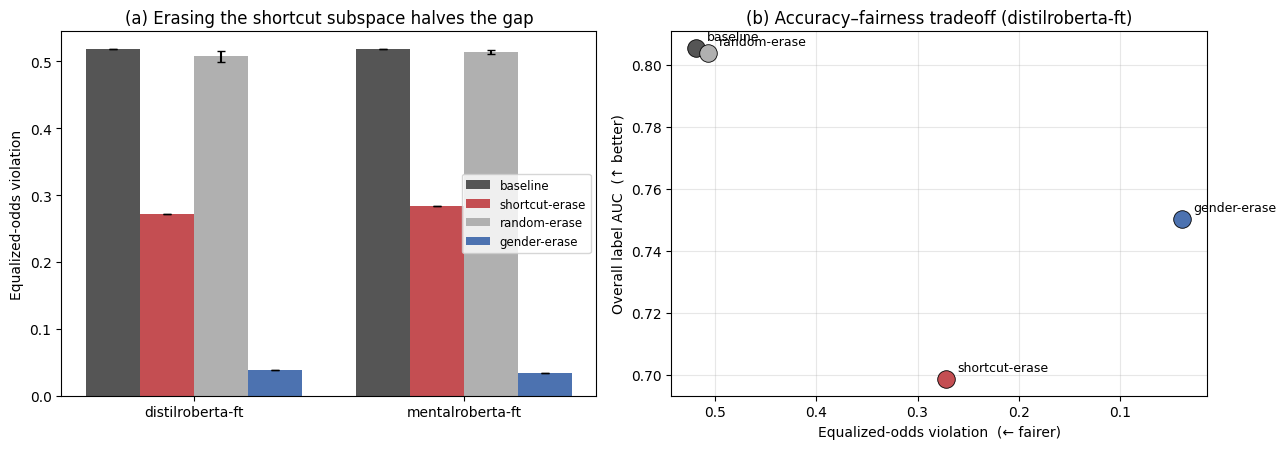

In [4]:
order = ['baseline', 'shortcut-erase', 'random-erase', 'gender-erase']
colors = {'baseline': '#555555', 'shortcut-erase': '#c44e52', 'random-erase': '#b0b0b0', 'gender-erase': '#4c72b0'}
models = list(MODELS); fig, ax = plt.subplots(1, 2, figsize=(13, 4.6)); w = 0.2; x = np.arange(len(models))
for j, cond in enumerate(order):
    vals = [res[(res.model == m) & (res.condition == cond)]['eo'].values[0] for m in models]
    errs = [(res[(res.model == m) & (res.condition == cond)].get('eo_sd', pd.Series([0])).values[0] if cond == 'random-erase' else 0) for m in models]
    errs = [0 if pd.isna(e) else e for e in errs]
    ax[0].bar(x + (j-1.5)*w, vals, w, yerr=errs, capsize=3, label=cond, color=colors[cond])
ax[0].set_xticks(x); ax[0].set_xticklabels(models); ax[0].set_ylabel('Equalized-odds violation')
ax[0].set_title('(a) Erasing the shortcut subspace halves the gap'); ax[0].legend(fontsize=8.5)
d = res[res.model == 'distilroberta-ft']
for cond in order:
    row = d[d.condition == cond].iloc[0]
    ax[1].scatter(row['eo'], row['auc'], s=160, color=colors[cond], zorder=3, edgecolor='k', linewidth=.6)
    ax[1].annotate(cond, (row['eo'], row['auc']), textcoords='offset points', xytext=(8, 6), fontsize=9)
ax[1].set_xlabel('Equalized-odds violation  (← fairer)'); ax[1].set_ylabel('Overall label AUC  (↑ better)')
ax[1].set_title('(b) Accuracy–fairness tradeoff (distilroberta-ft)'); ax[1].invert_xaxis(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/causal_intervention.png', dpi=150, bbox_inches='tight')
print('saved ->', f'{OUT}/causal_intervention.png')